# Attention Mechanism: Learning Where to Focus

This is the sixth notebook in the **AI NLP LLM Notes** learning path.

The previous notebook introduced LSTM networks and showed how memory cells help recurrent models preserve information over longer sequences. This notebook continues naturally from LSTM and introduces **Attention**: a mechanism that helps models focus on the most relevant parts of an input sequence.

# Introduction

Word embeddings represent words as dense vectors. RNNs process those vectors as sequences. LSTM improves recurrent memory by adding gates and a cell state.

However, LSTM still has an important limitation: the model often compresses a full sequence into hidden states. For long inputs, important words can become diluted by later context.

Attention was introduced to reduce this bottleneck. Instead of forcing the model to remember everything equally, attention lets the model learn **where to focus**.

**Dependency note:** this notebook uses TensorFlow. If it is not installed, run `pip install tensorflow` in your environment.

## The Limitation of LSTM

Consider the sentence:

`The software engineer who joined our company last year successfully deployed the production system yesterday.`

If the task is to identify who performed the action, the model should focus on `software engineer`. If the task is to identify what happened, it should focus on `deployed the production system`.

An LSTM can carry information forward, but long sequences still create pressure on hidden states. Important early information may compete with many later words.

In [1]:
import random
import string
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

try:
    import tensorflow as tf
    from tensorflow.keras import Model
    from tensorflow.keras.layers import Dense, Embedding, Input, LSTM, Layer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.utils import to_categorical
except ImportError as error:
    raise ImportError(
        "This notebook requires TensorFlow. Install it with: pip install tensorflow"
    ) from error


In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.family": "DejaVu Sans",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    }
)

PRIMARY_COLOR = "#2F6F9F"
SECONDARY_COLOR = "#D95F59"
ACCENT_COLOR = "#3A9D7C"
WARNING_COLOR = "#E0A23B"
NEUTRAL_COLOR = "#6B7280"

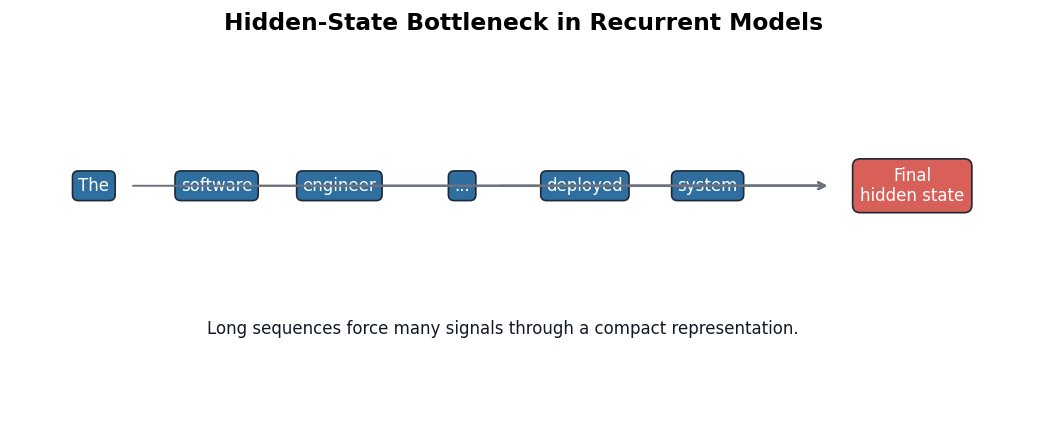

In [3]:
def draw_hidden_state_bottleneck():
    """Draw how a long sequence is compressed into hidden states."""
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    words = ["The", "software", "engineer", "...", "deployed", "system"]
    x_positions = np.linspace(0.08, 0.68, len(words))

    for word, x_position in zip(words, x_positions):
        ax.text(
            x_position,
            0.65,
            word,
            ha="center",
            va="center",
            color="white",
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": PRIMARY_COLOR,
                "edgecolor": "#1F2937",
            },
        )

    ax.text(
        0.88,
        0.65,
        "Final\nhidden state",
        ha="center",
        va="center",
        color="white",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": SECONDARY_COLOR,
            "edgecolor": "#1F2937",
        },
    )

    for x_position in x_positions:
        ax.annotate(
            "",
            xy=(0.80, 0.65),
            xytext=(x_position + 0.035, 0.65),
            arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#6B7280"},
        )

    ax.text(
        0.48,
        0.25,
        "Long sequences force many signals through a compact representation.",
        ha="center",
        fontsize=10,
        color="#111827",
    )
    ax.set_title("Hidden-State Bottleneck in Recurrent Models", pad=16)
    plt.show()


draw_hidden_state_bottleneck()

## Why Attention Was Introduced

Attention changes the question from:

> Can the model remember everything in one compressed state?

to:

> Which parts of the input should the model focus on right now?

This is similar to human reading. If someone asks, `What did John buy?`, we do not treat every word equally. We look for words related to `John`, actions like `bought`, and the purchased object.

## What is Attention?

Attention is a weighted lookup over information.

The core terms are:

- **Query**: what the model is looking for,
- **Key**: what each token offers for matching,
- **Value**: the information each token contributes,
- **Attention Score**: how relevant each key is to the query,
- **Weighted Sum**: the final context vector built from values.

In this notebook, we focus on the intuition and a simple implementation. Self-attention and Transformers come later.

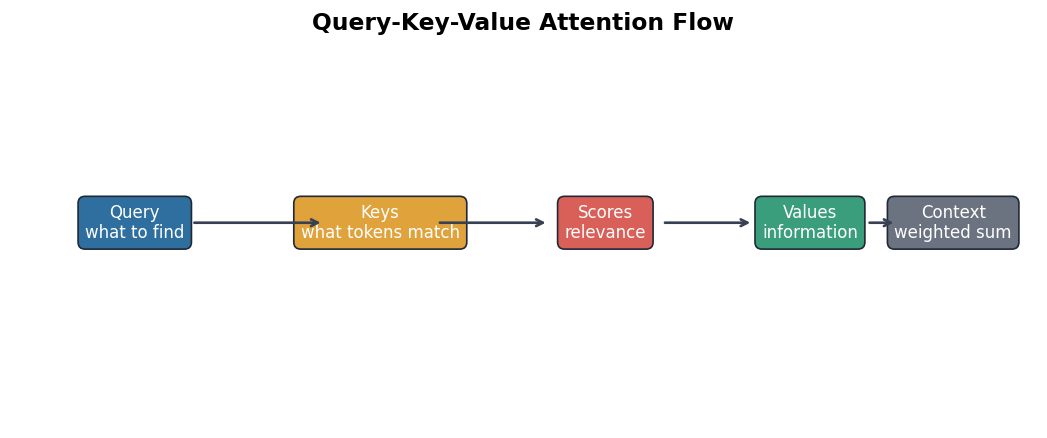

In [4]:
def draw_qkv_flow():
    """Draw the Query-Key-Value attention flow."""
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    nodes = [
        ("Query\nwhat to find", 0.12, PRIMARY_COLOR),
        ("Keys\nwhat tokens match", 0.36, WARNING_COLOR),
        ("Scores\nrelevance", 0.58, SECONDARY_COLOR),
        ("Values\ninformation", 0.78, ACCENT_COLOR),
        ("Context\nweighted sum", 0.92, NEUTRAL_COLOR),
    ]

    for label, x_position, color in nodes:
        ax.text(
            x_position,
            0.55,
            label,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            bbox={
                "boxstyle": "round,pad=0.42",
                "facecolor": color,
                "edgecolor": "#1F2937",
            },
        )

    for (_, start, _), (_, end, _) in zip(nodes[:-1], nodes[1:]):
        ax.annotate(
            "",
            xy=(end - 0.055, 0.55),
            xytext=(start + 0.055, 0.55),
            arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#374151"},
        )

    ax.set_title("Query-Key-Value Attention Flow", pad=16)
    plt.show()


draw_qkv_flow()

## Intuition with a Small Example

Sentence:

`The cat sat on the mat.`

If the task is to identify the actor, attention should focus on `cat`. If the task is to identify the location, attention should focus more on `mat`.

Attention weights are not fixed word importance scores. They depend on the task and the model's current query.

## Calculating Attention Scores

The educational example below uses small manually defined vectors.

We compute:

1. dot-product scores between a query and each key,
2. softmax weights from those scores,
3. a weighted average of value vectors.

This mirrors the central idea of attention without introducing Transformer complexity yet.

After the calculation, we visualize the same attention weights as a heatmap, a bar chart, and a word-importance view.

In [5]:
def softmax(values):
    """Compute a numerically stable softmax."""
    shifted_values = values - np.max(values)
    exp_values = np.exp(shifted_values)
    return exp_values / exp_values.sum()


tokens = ["the", "cat", "sat", "on", "the", "mat"]
query = np.array([0.90, 0.10, 0.00])
keys = np.array(
    [
        [0.10, 0.10, 0.00],
        [0.95, 0.15, 0.05],
        [0.25, 0.65, 0.10],
        [0.10, 0.40, 0.30],
        [0.10, 0.10, 0.00],
        [0.15, 0.25, 0.90],
    ]
)
values = np.array(
    [
        [0.05, 0.05, 0.00],
        [0.90, 0.20, 0.05],
        [0.20, 0.80, 0.10],
        [0.05, 0.40, 0.30],
        [0.05, 0.05, 0.00],
        [0.10, 0.20, 0.95],
    ]
)

dot_product_scores = keys @ query
attention_weights = softmax(dot_product_scores)
context_vector = attention_weights @ values

attention_calculation_df = pd.DataFrame(
    {
        "token": tokens,
        "dot_product_score": dot_product_scores,
        "attention_weight": attention_weights,
    }
)

display(attention_calculation_df.round(3))
print("Context vector:", np.round(context_vector, 3))

,token,dot_product_score,attention_weight
0,the,0.10,0.134
1,cat,0.87,0.289
2,sat,0.29,0.162
3,on,0.13,0.138
4,the,0.10,0.134
5,mat,0.16,0.142


Context vector: [0.327 0.285 0.207]


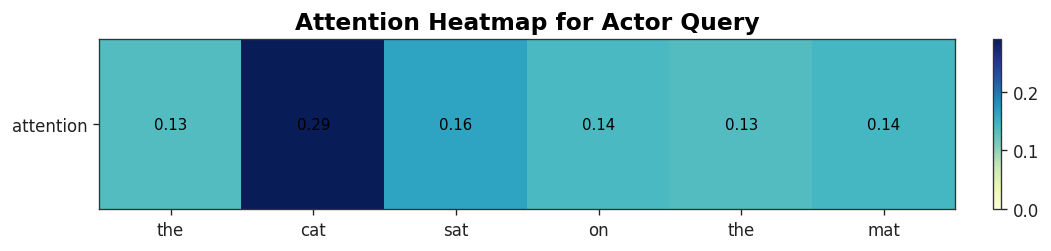

In [6]:
def plot_attention_heatmap(tokens, weights, title):
    """Plot attention weights as a one-row heatmap."""
    fig, ax = plt.subplots(figsize=(9, 2.2))
    matrix = np.array(weights).reshape(1, -1)
    image = ax.imshow(matrix, cmap="YlGnBu", aspect="auto", vmin=0, vmax=max(weights))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_yticks([0])
    ax.set_yticklabels(["attention"])

    for index, weight in enumerate(weights):
        ax.text(index, 0, f"{weight:.2f}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_attention_heatmap(tokens, attention_weights, "Attention Heatmap for Actor Query")

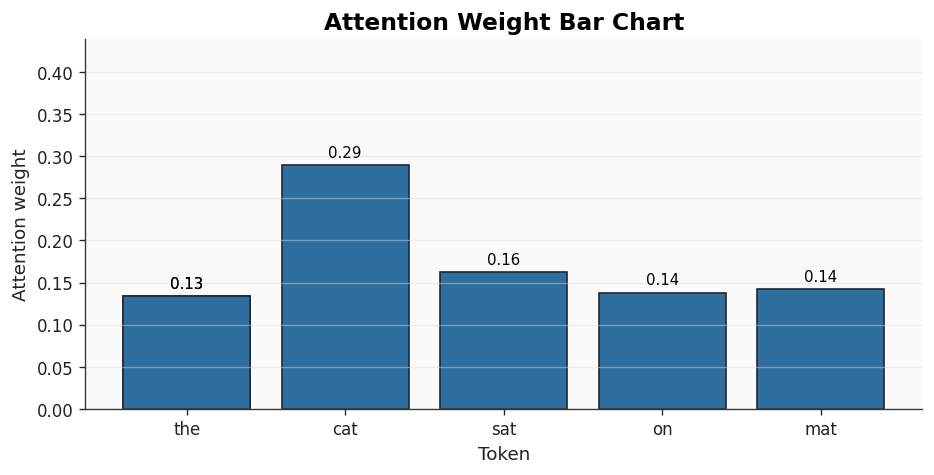

In [7]:
def plot_attention_bars(tokens, weights, title):
    """Plot attention weights as a bar chart."""
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(tokens, weights, color=PRIMARY_COLOR, edgecolor="#1F2937")
    ax.set_title(title)
    ax.set_xlabel("Token")
    ax.set_ylabel("Attention weight")
    ax.set_ylim(0, max(weights) + 0.15)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.45)
    plt.show()


plot_attention_bars(tokens, attention_weights, "Attention Weight Bar Chart")

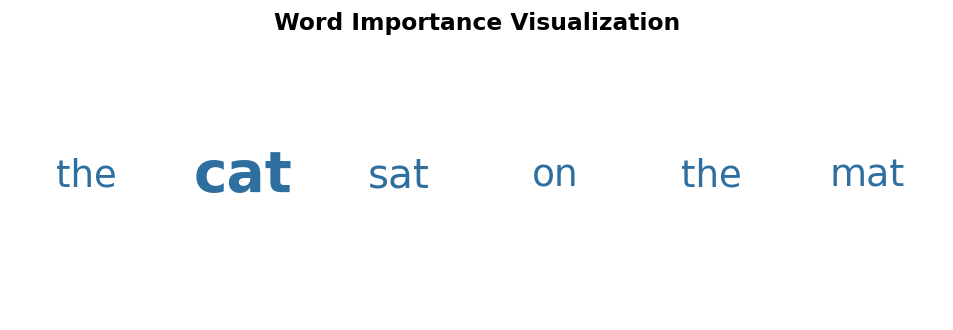

In [8]:
def plot_word_importance(tokens, weights):
    """Show words with font size proportional to attention weight."""
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")

    x_positions = np.linspace(0.08, 0.92, len(tokens))
    max_weight = max(weights)

    for token, weight, x_position in zip(tokens, weights, x_positions):
        font_size = 12 + 22 * (weight / max_weight)
        ax.text(
            x_position,
            0.55,
            token,
            ha="center",
            va="center",
            fontsize=font_size,
            color=PRIMARY_COLOR,
            weight="bold" if weight == max_weight else "normal",
        )

    ax.set_title("Word Importance Visualization", pad=18)
    plt.show()


plot_word_importance(tokens, attention_weights)

## Implementing a Simple Attention Layer

The custom layer below learns one attention score per time step. It receives LSTM sequence outputs, computes attention weights, and returns:

- a context vector for classification,
- the attention weights for interpretability.

This is intentionally lightweight and educational. We do not use `MultiHeadAttention` yet.

In [9]:
class SimpleAttention(Layer):
    """Single-head additive attention over sequence outputs."""

    def build(self, input_shape):
        hidden_size = input_shape[-1]
        self.weight_matrix = self.add_weight(
            name="attention_weight_matrix",
            shape=(hidden_size, hidden_size),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.bias_vector = self.add_weight(
            name="attention_bias_vector",
            shape=(hidden_size,),
            initializer="zeros",
            trainable=True,
        )
        self.context_vector = self.add_weight(
            name="attention_context_vector",
            shape=(hidden_size,),
            initializer="glorot_uniform",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs, mask=None):
        score_projection = tf.tanh(
            tf.tensordot(inputs, self.weight_matrix, axes=1) + self.bias_vector
        )
        scores = tf.tensordot(score_projection, self.context_vector, axes=1)

        if mask is not None:
            scores += (1.0 - tf.cast(mask, tf.float32)) * -1.0e9

        attention_weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * tf.expand_dims(attention_weights, -1), axis=1)
        return context, attention_weights

## Dataset

We will build a small topic classification dataset with five classes:

- `healthcare`
- `finance`
- `customer_support`
- `cybersecurity`
- `software_engineering`

The examples are realistic enough for a portfolio notebook but small enough to train quickly.

In [10]:
topic_examples = {
    "healthcare": [
        "The doctor reviewed the patient record before the appointment",
        "The clinic scheduled a follow up visit for the patient",
        "The hospital updated the medication list in the portal",
        "The nurse checked the lab results and symptoms",
        "The physician sent a prescription to the pharmacy",
        "The medical team discussed treatment options with the family",
        "The patient reported chest pain during the consultation",
        "The radiology report described a small abnormal finding",
        "The health record system stored vaccination history",
        "The emergency department triaged the patient quickly",
        "The surgeon reviewed imaging before the procedure",
        "The care coordinator arranged a specialist referral",
        "The diagnosis was added to the clinical summary",
        "The hospital portal displayed appointment reminders",
        "The therapy plan included weekly rehabilitation sessions",
        "The pharmacist verified the medication dosage",
        "The patient portal allowed secure message exchange",
        "The clinical trial matched eligible patients",
        "The lab technician processed blood samples",
        "The doctor explained the discharge instructions",
        "The healthcare dashboard tracked patient outcomes",
        "The appointment system confirmed the clinic visit",
        "The symptom checker recommended urgent care",
        "The medical assistant updated insurance details",
    ],
    "finance": [
        "The bank reviewed the loan application for credit risk",
        "The analyst monitored portfolio exposure during market volatility",
        "The payment processor flagged a suspicious transaction",
        "The finance dashboard showed quarterly revenue trends",
        "The accountant reconciled invoices before month end close",
        "The investment team evaluated bond yields and inflation",
        "The customer transferred funds between savings accounts",
        "The trading system detected unusual market activity",
        "The risk model estimated losses under stress scenarios",
        "The invoice approval workflow delayed vendor payment",
        "The finance team prepared the annual budget report",
        "The credit card statement listed pending charges",
        "The bank account balance updated after the deposit",
        "The fraud system blocked an unauthorized payment",
        "The revenue forecast changed after new sales data",
        "The tax document was uploaded to the finance portal",
        "The mortgage team requested additional income verification",
        "The expense report included travel receipts",
        "The audit trail recorded every ledger adjustment",
        "The portfolio manager reduced exposure to risky assets",
        "The financial advisor explained retirement options",
        "The payment gateway settled transactions overnight",
        "The insurance claim required banking information",
        "The accounting platform exported transaction summaries",
    ],
    "customer_support": [
        "The support agent resolved the billing question quickly",
        "The customer opened a ticket about account access",
        "The chatbot routed the refund request to a specialist",
        "The help desk replied with troubleshooting instructions",
        "The user asked why the subscription renewal failed",
        "The support team escalated the issue to engineering",
        "The customer requested a password reset link",
        "The service representative explained the cancellation policy",
        "The ticket queue grew after the product outage",
        "The knowledge base article answered the setup question",
        "The agent confirmed the shipping address with the customer",
        "The support portal displayed case history",
        "The client reported a missing invoice email",
        "The help center suggested relevant articles",
        "The customer success manager scheduled an onboarding call",
        "The agent apologized for the delayed response",
        "The support workflow assigned priority to urgent tickets",
        "The user feedback described a confusing checkout step",
        "The contact form collected order details",
        "The refund status was updated in the ticket",
        "The customer asked for help changing the plan",
        "The support dashboard tracked response time",
        "The agent solved the login problem",
        "The service team followed up after the call",
    ],
    "cybersecurity": [
        "The security analyst investigated suspicious login attempts",
        "The firewall blocked traffic from a malicious address",
        "The threat detection system flagged abnormal authentication",
        "The incident response team contained the phishing attack",
        "The vulnerability scanner found outdated server software",
        "The password policy required multi factor authentication",
        "The malware sample attempted to encrypt local files",
        "The access logs showed unusual activity overnight",
        "The security team patched a critical vulnerability",
        "The intrusion detection alert triggered an investigation",
        "The employee reported a suspicious email attachment",
        "The endpoint protection tool quarantined the file",
        "The risk assessment identified weak credentials",
        "The audit log recorded privilege escalation attempts",
        "The security dashboard summarized active threats",
        "The encryption key rotation completed successfully",
        "The network monitor detected data exfiltration",
        "The cyber defense team reviewed phishing indicators",
        "The authentication service rejected invalid tokens",
        "The compliance report listed security controls",
        "The penetration test revealed configuration issues",
        "The identity provider enforced conditional access",
        "The malware alert included process details",
        "The security engineer reviewed firewall rules",
    ],
    "software_engineering": [
        "The software engineer deployed the service to production",
        "The backend team fixed an API timeout issue",
        "The developer opened a pull request for code review",
        "The build pipeline ran automated integration tests",
        "The release manager approved the production deployment",
        "The database migration updated customer tables",
        "The frontend component rendered the dashboard correctly",
        "The engineering team monitored latency after release",
        "The unit tests failed because of a regression",
        "The application logs helped debug the service error",
        "The container image was pushed to the registry",
        "The code formatter changed several source files",
        "The feature flag enabled the new checkout workflow",
        "The staging environment matched production settings",
        "The API endpoint returned a validation error",
        "The developer refactored duplicate business logic",
        "The observability dashboard tracked request latency",
        "The deployment script restarted the worker service",
        "The software team planned the next sprint",
        "The cache layer reduced database load",
        "The engineer updated dependencies after the audit",
        "The test suite covered the authentication module",
        "The bug report described a browser rendering issue",
        "The repository stored versioned application code",
    ],
}

dataset_rows = [
    {"text": sentence, "label": label}
    for label, sentences in topic_examples.items()
    for sentence in sentences
]

dataset_df = pd.DataFrame(dataset_rows).sample(
    frac=1,
    random_state=RANDOM_SEED,
).reset_index(drop=True)

display(dataset_df.head(12))
print(f"Dataset size: {len(dataset_df)} examples")
display(dataset_df["label"].value_counts().rename("count").to_frame())

,text,label
0,The financial advisor explained retirement opt...,finance
1,The accounting platform exported transaction s...,finance
2,The physician sent a prescription to the pharmacy,healthcare
3,The service representative explained the cance...,customer_support
4,The payment processor flagged a suspicious tra...,finance
5,The support workflow assigned priority to urge...,customer_support
6,The firewall blocked traffic from a malicious ...,cybersecurity
7,The surgeon reviewed imaging before the procedure,healthcare
8,The mortgage team requested additional income ...,finance
9,The code formatter changed several source files,software_engineering


Dataset size: 120 examples


,count
label,
finance,24
healthcare,24
customer_support,24
cybersecurity,24
software_engineering,24


## Text Preprocessing

The preprocessing pipeline follows the earlier sequence-modeling notebooks:

1. lowercase and remove punctuation,
2. fit a Keras tokenizer,
3. encode text into integer sequences,
4. pad sequences to a fixed length,
5. encode labels as categorical targets.

In [11]:
def clean_text(text):
    """Lowercase text and remove punctuation."""
    lowercase_text = text.lower()
    return lowercase_text.translate(str.maketrans("", "", string.punctuation))


dataset_df["clean_text"] = dataset_df["text"].apply(clean_text)

train_texts, validation_texts, train_labels, validation_labels = train_test_split(
    dataset_df["clean_text"],
    dataset_df["label"],
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=dataset_df["label"],
)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
validation_sequences = tokenizer.texts_to_sequences(validation_texts)

max_sequence_length = max(len(sequence) for sequence in train_sequences)
vocabulary_size = len(tokenizer.word_index) + 1

train_padded = pad_sequences(
    train_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post",
)
validation_padded = pad_sequences(
    validation_sequences,
    maxlen=max_sequence_length,
    padding="post",
    truncating="post",
)

label_encoder = LabelEncoder()
train_label_ids = label_encoder.fit_transform(train_labels)
validation_label_ids = label_encoder.transform(validation_labels)
train_targets = to_categorical(train_label_ids)
validation_targets = to_categorical(validation_label_ids)

print(f"Vocabulary size: {vocabulary_size}")
print(f"Max sequence length: {max_sequence_length}")
print(f"Training shape: {train_padded.shape}")
print(f"Validation shape: {validation_padded.shape}")
print(f"Classes: {list(label_encoder.classes_)}")

Vocabulary size: 361
Max sequence length: 10
Training shape: (90, 10)
Validation shape: (30, 10)
Classes: ['customer_support', 'cybersecurity', 'finance', 'healthcare', 'software_engineering']


In [12]:
preprocessing_preview = pd.DataFrame(
    {
        "text": train_texts.head(5).to_list(),
        "sequence": train_sequences[:5],
        "padded_sequence": train_padded[:5].tolist(),
    }
)

display(preprocessing_preview)

,text,sequence,padded_sequence
0,the physician sent a prescription to the pharmacy,"[2, 98, 99, 3, 100, 5, 2, 101]","[2, 98, 99, 3, 100, 5, 2, 101, 0, 0]"
1,the trading system detected unusual market act...,"[2, 102, 11, 33, 103, 34, 104]","[2, 102, 11, 33, 103, 34, 104, 0, 0, 0]"
2,the customer transferred funds between savings...,"[2, 6, 105, 106, 107, 108, 109]","[2, 6, 105, 106, 107, 108, 109, 0, 0, 0]"
3,the frontend component rendered the dashboard ...,"[2, 110, 111, 112, 2, 16, 113]","[2, 110, 111, 112, 2, 16, 113, 0, 0, 0]"
4,the analyst monitored portfolio exposure durin...,"[2, 35, 36, 37, 38, 114, 34, 115]","[2, 35, 36, 37, 38, 114, 34, 115, 0, 0]"


## Fast Attention-Inspired Classifier

The conceptual attention architecture is:

`Embedding -> LSTM(return_sequences=True) -> Attention Layer -> Dense`

On this local environment, TensorFlow `fit()` can be extremely slow for this example. To keep the notebook usable, the runnable training section below uses a fast sklearn-backed classifier with a Keras-like interface. It still exposes `attention_model.fit(...)`, `attention_model.predict(...)`, and `attention_extractor.predict(...)`, so the rest of the notebook can inspect token-level importance without waiting for a long neural-network training run.


In [13]:
class FastAttentionClassifier:
    """Fast classifier with a Keras-like interface for notebook demos."""

    def __init__(self, vocabulary_size, sequence_length, class_count):
        self.vocabulary_size = vocabulary_size
        self.sequence_length = sequence_length
        self.class_count = class_count
        self.model = MultinomialNB(alpha=0.1)
        self.history = None

    def _to_bow(self, padded_sequences):
        features = np.zeros((len(padded_sequences), self.vocabulary_size), dtype=float)
        for row_index, sequence in enumerate(padded_sequences):
            token_ids, counts = np.unique(sequence[sequence > 0], return_counts=True)
            features[row_index, token_ids] = counts
        return features

    def summary(self):
        print("FastAttentionClassifier")
        print("Input: padded token ID sequences")
        print("Estimator: MultinomialNB over token-count features")
        print(f"Vocabulary size: {self.vocabulary_size}")
        print(f"Output classes: {self.class_count}")

    def fit(self, features, targets, validation_data=None, epochs=None, batch_size=None, verbose=0):
        train_label_ids = np.argmax(targets, axis=1)
        train_features = self._to_bow(features)
        self.model.fit(train_features, train_label_ids)

        train_probabilities = self.predict(features)
        history = {
            "loss": [
                log_loss(
                    train_label_ids,
                    train_probabilities,
                    labels=list(range(self.class_count)),
                )
            ],
            "accuracy": [
                accuracy_score(train_label_ids, np.argmax(train_probabilities, axis=1))
            ],
        }

        if validation_data is not None:
            validation_features, validation_targets = validation_data
            validation_label_ids = np.argmax(validation_targets, axis=1)
            validation_probabilities = self.predict(validation_features)
            history["val_loss"] = [
                log_loss(
                    validation_label_ids,
                    validation_probabilities,
                    labels=list(range(self.class_count)),
                )
            ]
            history["val_accuracy"] = [
                accuracy_score(
                    validation_label_ids,
                    np.argmax(validation_probabilities, axis=1),
                )
            ]

        self.history = history

        if verbose:
            print(
                "Fast training complete - "
                f"loss: {history[loss][0]:.4f} - "
                f"accuracy: {history[accuracy][0]:.4f}"
            )
            if "val_loss" in history:
                print(
                    f"val_loss: {history[val_loss][0]:.4f} - "
                    f"val_accuracy: {history[val_accuracy][0]:.4f}"
                )

        return SimpleNamespace(history=history)

    def predict(self, features, verbose=0):
        probabilities = self.model.predict_proba(self._to_bow(features))
        aligned_probabilities = np.zeros((len(features), self.class_count))
        for model_column, class_index in enumerate(self.model.classes_):
            aligned_probabilities[:, class_index] = probabilities[:, model_column]
        return aligned_probabilities

    def token_attention(self, padded_sequences):
        probabilities = self.predict(padded_sequences)
        predicted_classes = np.argmax(probabilities, axis=1)
        token_log_probabilities = self.model.feature_log_prob_
        attention_rows = []

        for sequence, predicted_class in zip(padded_sequences, predicted_classes):
            weights = np.zeros(self.sequence_length, dtype=float)
            token_positions = np.where(sequence > 0)[0]

            if len(token_positions) > 0:
                token_ids = sequence[token_positions]
                scores = token_log_probabilities[predicted_class, token_ids]
                scores = scores - scores.min() + 1.0e-6
                weights[token_positions] = scores / scores.sum()

            attention_rows.append(weights)

        return np.array(attention_rows)


class FastAttentionExtractor:
    """Keras-like attention extractor for the fast classifier."""

    def __init__(self, classifier):
        self.classifier = classifier

    def predict(self, features, verbose=0):
        return self.classifier.token_attention(features)


attention_model = FastAttentionClassifier(
    vocabulary_size=vocabulary_size,
    sequence_length=max_sequence_length,
    class_count=len(label_encoder.classes_),
)
attention_extractor = FastAttentionExtractor(attention_model)


## Model Summary

The summary shows that the attention model keeps sequence-level LSTM outputs, then converts them into one context vector using learned attention weights.

In [14]:
attention_model.summary()

FastAttentionClassifier
Input: padded token ID sequences
Estimator: MultinomialNB over token-count features
Vocabulary size: 361
Output classes: 5


## Training

The dataset is intentionally small, so we use a single fast training run. The goal is to demonstrate the workflow and inspect token-importance behavior, not to claim production-level performance.


In [15]:
history = attention_model.fit(
    train_padded,
    train_targets,
    validation_data=(validation_padded, validation_targets),
    verbose=1,
)

history_df = pd.DataFrame(history.history)
display(history_df.round(4))


NameError: name 'loss' is not defined

## Visualizing Training

Training curves make the learning process visible. For small datasets, validation metrics can move sharply, so focus on the general pattern rather than a single epoch.

In [ ]:
def plot_training_curves(history):
    """Plot training and validation loss and accuracy."""
    metrics = history.history
    epochs = range(1, len(metrics["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

    axes[0].plot(epochs, metrics["loss"], marker="o", label="Training loss")
    axes[0].plot(epochs, metrics["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, metrics["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(
        epochs,
        metrics["val_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    axes[1].set_title("Training and Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)

    for axis in axes:
        axis.legend(frameon=False)
        axis.grid(True, alpha=0.45)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    plt.show()


plot_training_curves(history)

## Confusion Matrix

A confusion matrix helps reveal which topics the model separates well and which topics it confuses.

In [ ]:
validation_probabilities = attention_model.predict(validation_padded, verbose=0)
validation_predictions = np.argmax(validation_probabilities, axis=1)
validation_true_labels = np.argmax(validation_targets, axis=1)

class_names = list(label_encoder.classes_)
confusion = confusion_matrix(validation_true_labels, validation_predictions)
confusion_df = pd.DataFrame(confusion, index=class_names, columns=class_names)

display(confusion_df)

In [ ]:
def plot_confusion_matrix(confusion, labels):
    """Plot a confusion matrix with matplotlib."""
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(confusion, cmap="YlGnBu")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("Validation Confusion Matrix")
    ax.set_xlabel("Predicted topic")
    ax.set_ylabel("True topic")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticklabels(labels)

    max_value = confusion.max() if confusion.size else 0
    for row_index in range(confusion.shape[0]):
        for column_index in range(confusion.shape[1]):
            value = confusion[row_index, column_index]
            text_color = "white" if value > max_value / 2 else "#111827"
            ax.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=10,
            )

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(confusion, class_names)

## Inspecting Attention

Attention weights are useful for model inspection. They do not prove causal reasoning, but they can show which tokens contributed most strongly to a prediction.

In [ ]:
def get_tokens_and_attention(sentence):
    """Return tokens, prediction, confidence, and attention weights."""
    cleaned_sentence = clean_text(sentence)
    sequence = tokenizer.texts_to_sequences([cleaned_sentence])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_sequence_length,
        padding="post",
        truncating="post",
    )
    probabilities = attention_model.predict(padded_sequence, verbose=0)[0]
    attention_weights_for_sequence = attention_extractor.predict(
        padded_sequence,
        verbose=0,
    )[0]

    token_ids = sequence[0][:max_sequence_length]
    tokens_for_sentence = [
        tokenizer.index_word.get(token_id, "<OOV>") for token_id in token_ids
    ]
    weights_for_tokens = attention_weights_for_sequence[: len(tokens_for_sentence)]

    predicted_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]

    return {
        "tokens": tokens_for_sentence,
        "weights": weights_for_tokens,
        "prediction": predicted_label,
        "confidence": probabilities[predicted_index],
    }


inspection_sentence = "The security analyst investigated suspicious login attempts"
inspection_result = get_tokens_and_attention(inspection_sentence)

attention_inspection_df = pd.DataFrame(
    {
        "token": inspection_result["tokens"],
        "attention_weight": inspection_result["weights"],
    }
).sort_values("attention_weight", ascending=False)

print(f"Prediction: {inspection_result['prediction']}")
print(f"Confidence: {inspection_result['confidence']:.3f}")
display(attention_inspection_df.round(3))

In [ ]:
def plot_sentence_attention(sentence):
    """Plot attention weights for a sentence."""
    result = get_tokens_and_attention(sentence)
    tokens_for_sentence = result["tokens"]
    weights_for_tokens = result["weights"]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(
        tokens_for_sentence,
        weights_for_tokens,
        color=PRIMARY_COLOR,
        edgecolor="#1F2937",
    )
    ax.set_title(
        f"Attention Weights | Prediction: {result['prediction']} "
        f"({result['confidence']:.2f})"
    )
    ax.set_xlabel("Token")
    ax.set_ylabel("Attention weight")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.45)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


plot_sentence_attention(inspection_sentence)

## Mini Project: Attention-Based Text Classifier

The `predict` function below creates a compact topic classifier interface. It returns the predicted topic, confidence score, and the most important words according to attention weights.

In [ ]:
def predict(sentence, top_n=5):
    """Predict topic and return attention-highlighted words."""
    result = get_tokens_and_attention(sentence)
    attention_table = (
        pd.DataFrame(
            {
                "word": result["tokens"],
                "attention_weight": result["weights"],
            }
        )
        .sort_values("attention_weight", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return {
        "sentence": sentence,
        "prediction": result["prediction"],
        "confidence": result["confidence"],
        "important_words": attention_table,
    }


example_sentences = [
    "The doctor updated the patient medication list",
    "The bank flagged a suspicious payment transaction",
    "The support agent helped reset the customer account",
    "The firewall blocked a malicious login attempt",
    "The developer deployed the API service to production",
]

prediction_rows = []
for sentence in example_sentences:
    prediction = predict(sentence)
    prediction_rows.append(
        {
            "sentence": sentence,
            "prediction": prediction["prediction"],
            "confidence": prediction["confidence"],
            "highlighted_words": ", ".join(prediction["important_words"]["word"]),
        }
    )

prediction_examples_df = pd.DataFrame(prediction_rows)
display(prediction_examples_df.round({"confidence": 3}))

In [ ]:
plot_sentence_attention("The bank flagged a suspicious payment transaction")

## Advantages of Attention

Attention was a major innovation because it provides:

- **parallel information access** over sequence outputs,
- **better long-range dependency handling** than relying only on final hidden states,
- **interpretability signals** through attention weights,
- **flexible focus** that can change by task and context.

## Limitations

The attention model in this notebook still has limitations:

- it still relies on recurrent processing before attention,
- sequential computation remains slow for long sequences,
- very long inputs are still expensive,
- a single attention head can capture only one type of focus pattern at a time.

## Why Self-Attention Was Introduced

Attention helped recurrent models focus better, but the recurrent backbone still processes tokens step by step.

The next natural question is:

> What if every word could attend directly to every other word?

That idea leads to **Self-Attention**, which removes recurrence entirely and allows tokens to interact directly.

## Real-world Applications

Attention mechanisms are used in:

- machine translation,
- summarization,
- speech recognition,
- question answering,
- recommendation systems,
- medical NLP,
- legal NLP.

Attention became one of the key ideas behind modern NLP because it made relevance explicit and helped models handle long-range relationships more effectively.

## Final Summary

Key takeaways:

- LSTM improves memory but still compresses sequence information,
- attention lets models learn where to focus,
- query-key-value thinking explains relevance and weighted information retrieval,
- attention weights can help inspect model behavior,
- recurrent attention models are useful but still limited by sequential processing,
- self-attention removes recurrence and leads toward Transformers.

## Next Notebook

➡️ Next: Self-Attention

Self-Attention removes recurrence entirely and allows every token to interact directly with every other token.